In [1]:
# ============================================================
# Lab 6: Sparse Autoencoder for CIFAR-10 Feature Representation
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# ── 1. Device Configuration ──────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
# ── 2. Hyperparameters ───────────────────────────────────────
INPUT_DIM    = 3072          # 32×32×3 flattened
HIDDEN_DIM   = 1024          # Encoder hidden size
LATENT_DIM   = 512           # Bottleneck dimension
BATCH_SIZE   = 128
EPOCHS       = 20
LR           = 1e-3
SPARSITY_TARGET  = 0.05      # ρ  – desired average activation
SPARSITY_WEIGHT  = 1e-3      # β  – penalty weight (try: 1e-4, 1e-3, 1e-2)

In [4]:
# ── 3. Dataset: CIFAR-10 ─────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),                          # [0,1]
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))  # [-1,1]
])

train_data = datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_data)} | Test samples: {len(test_data)}")

100%|██████████| 170M/170M [00:02<00:00, 64.1MB/s]


Train samples: 50000 | Test samples: 10000


In [5]:
# ── 4. Sparse Autoencoder Model ──────────────────────────────
class SparseAutoencoder(nn.Module):
    """
    Architecture
    ─────────────
    Encoder : INPUT_DIM → HIDDEN_DIM → LATENT_DIM  (ReLU activations)
    Decoder : LATENT_DIM → HIDDEN_DIM → INPUT_DIM  (Tanh on output)
    Sparsity: KL-divergence penalty on latent activations
    """

    def __init__(self):
        super(SparseAutoencoder, self).__init__()

        # ── Encoder ──
        self.encoder = nn.Sequential(
            nn.Linear(INPUT_DIM, HIDDEN_DIM),
            nn.BatchNorm1d(HIDDEN_DIM),
            nn.ReLU(inplace=True),
            nn.Linear(HIDDEN_DIM, LATENT_DIM),
            nn.ReLU(inplace=True)           # keeps activations ≥ 0 for KL penalty
        )

        # ── Decoder ──
        self.decoder = nn.Sequential(
            nn.Linear(LATENT_DIM, HIDDEN_DIM),
            nn.BatchNorm1d(HIDDEN_DIM),
            nn.ReLU(inplace=True),
            nn.Linear(HIDDEN_DIM, INPUT_DIM),
            nn.Tanh()                       # matches [-1,1] normalised input
        )

    def forward(self, x):
        x       = x.view(x.size(0), -1)    # flatten
        latent  = self.encoder(x)
        recon   = self.decoder(latent)
        return recon, latent

In [6]:
# ── 5. KL-Divergence Sparsity Penalty ────────────────────────
def kl_divergence(rho, rho_hat):
    """
    KL( ρ || ρ̂ )  element-wise, then summed over latent neurons.
    rho     : scalar target sparsity
    rho_hat : mean activation per neuron across batch  (shape: [LATENT_DIM])
    """
    rho_hat = torch.clamp(rho_hat, 1e-8, 1 - 1e-8)   # numerical stability
    kl = rho * torch.log(rho / rho_hat) + \
         (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))
    return kl.sum()

In [7]:
# ── 6. Training Loop ─────────────────────────────────────────
def train(model, loader, optimizer, epoch):
    model.train()
    total_loss = total_recon = total_sparse = 0.0

    for batch_idx, (images, _) in enumerate(loader):
        images = images.to(device)

        optimizer.zero_grad()
        recon, latent = model(images)

        # Flatten original for MSE
        target = images.view(images.size(0), -1)

        # Reconstruction loss (MSE)
        recon_loss = nn.MSELoss()(recon, target)

        # Sparsity penalty (KL divergence)
        rho_hat     = latent.mean(dim=0)           # avg activation per neuron
        sparse_loss = kl_divergence(SPARSITY_TARGET, rho_hat)

        # Total loss
        loss = recon_loss + SPARSITY_WEIGHT * sparse_loss
        loss.backward()
        optimizer.step()

        total_loss   += loss.item()
        total_recon  += recon_loss.item()
        total_sparse += sparse_loss.item()

    n = len(loader)
    print(f"Epoch [{epoch:>2}/{EPOCHS}]  "
          f"Total: {total_loss/n:.4f}  "
          f"Recon: {total_recon/n:.4f}  "
          f"Sparse: {total_sparse/n:.4f}")
    return total_recon / n

In [8]:
# ── 7. Evaluation ────────────────────────────────────────────
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            recon, _ = model(images)
            target   = images.view(images.size(0), -1)
            total_loss += nn.MSELoss()(recon, target).item()
    avg = total_loss / len(loader)
    print(f"\nTest Reconstruction Loss: {avg:.4f}")
    return avg

In [9]:
# ── 8. Build, Train, Evaluate ────────────────────────────────
model     = SparseAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

print("\nModel Architecture:")
print(model)
print(f"\nTotal Parameters: {sum(p.numel() for p in model.parameters()):,}\n")

train_losses = []
for epoch in range(1, EPOCHS + 1):
    loss = train(model, train_loader, optimizer, epoch)
    train_losses.append(loss)
    scheduler.step()

test_loss = evaluate(model, test_loader)


Model Architecture:
SparseAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=3072, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=512, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=1024, out_features=3072, bias=True)
    (4): Tanh()
  )
)

Total Parameters: 7,349,760

Epoch [ 1/20]  Total: 0.0906  Recon: 0.0820  Sparse: 8.5185
Epoch [ 2/20]  Total: 0.0672  Recon: 0.0592  Sparse: 7.9934
Epoch [ 3/20]  Total: 0.0607  Recon: 0.0531  Sparse: 7.6971
Epoch [ 4/20]  Total: 0.0568  Recon: 0.0493  Sparse: 7.5352
Epoch [ 5/20]  Total: 0.0527  Recon: 0.0461  Sparse: 6.5385
Epoch [ 6/20]  Total: 0.0495  Reco

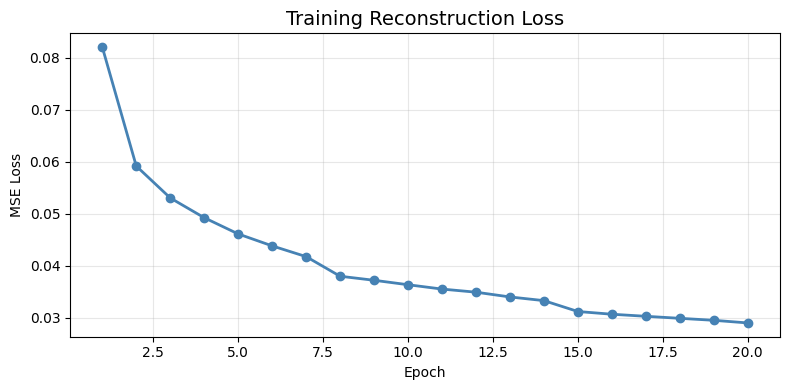

In [10]:
# ── 9. Plot Training Loss Curve ──────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o', linewidth=2, color='steelblue')
plt.title("Training Reconstruction Loss", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()

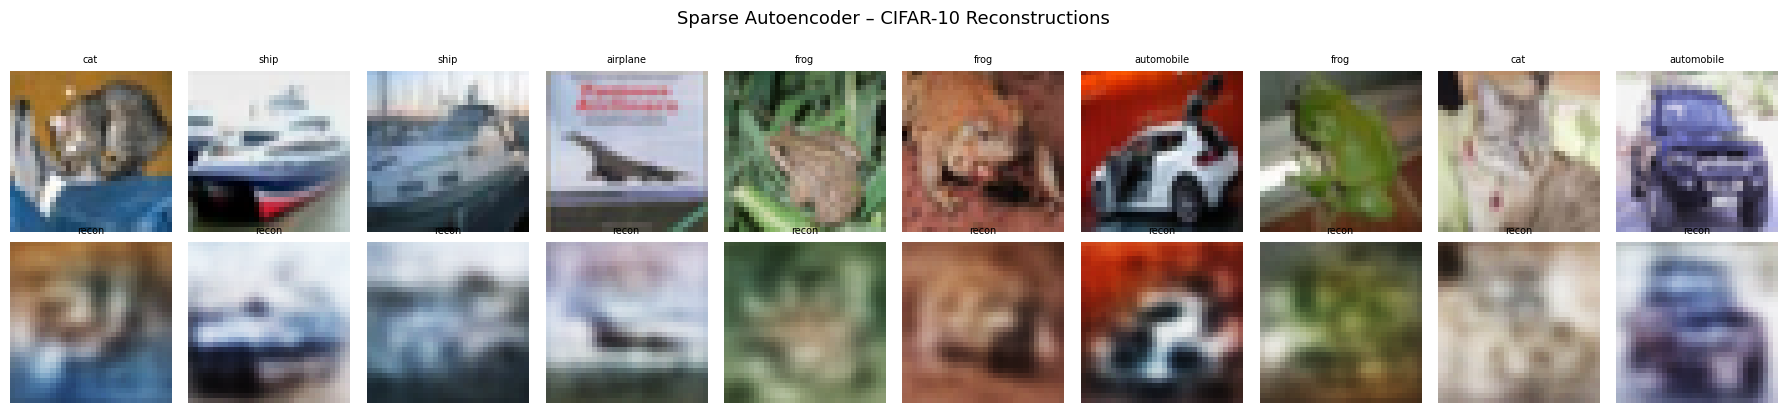


Latent vector stats (first sample):
  Shape : torch.Size([512])
  Mean  : 0.0401
  Sparsity (% zeros): 59.4%


In [11]:
# ── 10. Visualise: Original vs Reconstructed ─────────────────
CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

def denormalize(tensor):
    """Reverse [-1,1] normalisation for display."""
    return tensor * 0.5 + 0.5

def visualize_reconstructions(model, loader, n=10):
    model.eval()
    images, labels = next(iter(loader))
    images = images[:n].to(device)

    with torch.no_grad():
        recon, latent = model(images)

    # Reshape back to [N, C, H, W]
    recon = recon.view(-1, 3, 32, 32).cpu()
    images_cpu = images.cpu()

    fig, axes = plt.subplots(2, n, figsize=(18, 4))
    for i in range(n):
        # Original
        orig = denormalize(images_cpu[i]).permute(1, 2, 0).numpy()
        axes[0, i].imshow(np.clip(orig, 0, 1))
        axes[0, i].set_title(CLASSES[labels[i]], fontsize=7)
        axes[0, i].axis('off')

        # Reconstructed
        rec = denormalize(recon[i]).permute(1, 2, 0).numpy()
        axes[1, i].imshow(np.clip(rec, 0, 1))
        axes[1, i].set_title("recon", fontsize=7)
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel("Original",      fontsize=11)
    axes[1, 0].set_ylabel("Reconstructed", fontsize=11)
    plt.suptitle("Sparse Autoencoder – CIFAR-10 Reconstructions", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig("reconstructions.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("\nLatent vector stats (first sample):")
    print(f"  Shape : {latent[0].shape}")
    print(f"  Mean  : {latent[0].mean().item():.4f}")
    print(f"  Sparsity (% zeros): {(latent[0] == 0).float().mean().item()*100:.1f}%")

visualize_reconstructions(model, test_loader)



── Sparsity Regularization Experiment ──
  β=0.0     Test MSE=0.0369  Sparsity=46.2%
  β=0.0001  Test MSE=0.0402  Sparsity=70.0%
  β=0.001   Test MSE=0.0433  Sparsity=76.8%
  β=0.01    Test MSE=0.0485  Sparsity=78.6%


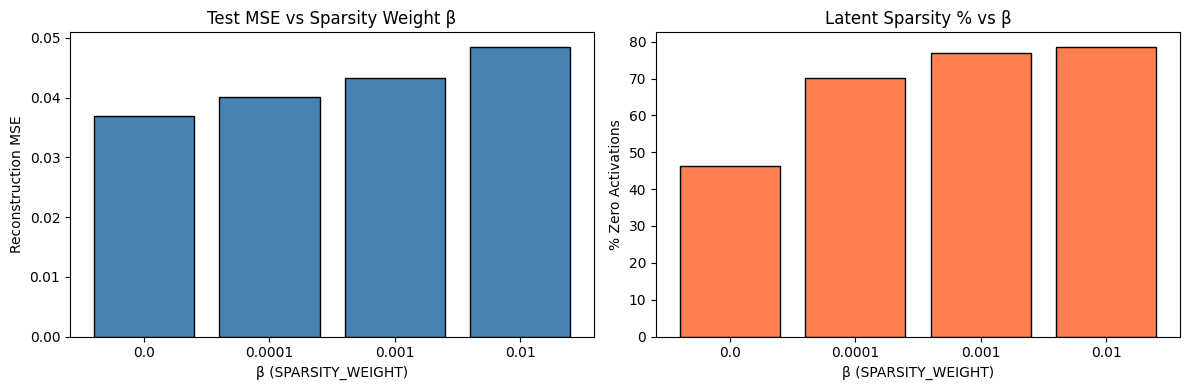

In [12]:
# ── 11. Sparsity Experiment ───────────────────────────────────
print("\n── Sparsity Regularization Experiment ──")
sparsity_values = [0.0, 1e-4, 1e-3, 1e-2]
exp_results = {}

for beta in sparsity_values:
    exp_model = SparseAutoencoder().to(device)
    exp_opt   = optim.Adam(exp_model.parameters(), lr=LR)
    exp_model.train()

    for ep in range(1, 6):   # 5 quick epochs per setting
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            exp_opt.zero_grad()
            recon, latent = exp_model(imgs)
            target = imgs.view(imgs.size(0), -1)
            r_loss = nn.MSELoss()(recon, target)
            rho_hat = latent.mean(dim=0)
            s_loss = kl_divergence(SPARSITY_TARGET, rho_hat) if beta > 0 else torch.tensor(0.0)
            (r_loss + beta * s_loss).backward()
            exp_opt.step()

    # Measure test loss + sparsity ratio
    exp_model.eval()
    t_loss, sparsity_ratio = 0.0, 0.0
    with torch.no_grad():
        for imgs, _ in test_loader:
            imgs   = imgs.to(device)
            r, lat = exp_model(imgs)
            t_loss += nn.MSELoss()(r, imgs.view(imgs.size(0), -1)).item()
            sparsity_ratio += (lat == 0).float().mean().item()
    exp_results[beta] = {
        "test_loss": t_loss / len(test_loader),
        "sparsity" : sparsity_ratio / len(test_loader) * 100
    }
    print(f"  β={beta:<6}  Test MSE={exp_results[beta]['test_loss']:.4f}  "
          f"Sparsity={exp_results[beta]['sparsity']:.1f}%")

# Plot experiment
betas  = [str(b) for b in sparsity_values]
losses = [exp_results[b]["test_loss"] for b in sparsity_values]
spars  = [exp_results[b]["sparsity"]  for b in sparsity_values]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(betas, losses, color='steelblue', edgecolor='black')
ax1.set_title("Test MSE vs Sparsity Weight β")
ax1.set_xlabel("β (SPARSITY_WEIGHT)")
ax1.set_ylabel("Reconstruction MSE")

ax2.bar(betas, spars, color='coral', edgecolor='black')
ax2.set_title("Latent Sparsity % vs β")
ax2.set_xlabel("β (SPARSITY_WEIGHT)")
ax2.set_ylabel("% Zero Activations")

plt.tight_layout()
plt.savefig("sparsity_experiment.png", dpi=150)
plt.show()